In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(
    "supply_chain_data.csv"
)

In [4]:
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [5]:
df.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

In [7]:
df.isnull().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [8]:
df.isnull().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [9]:
df.fillna(
    method='ffill',
    inplace=True
)

C:\Users\falco\AppData\Local\Temp\ipykernel_5128\2136877992.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop_duplicates(
    inplace=True
)

In [12]:
df.to_csv(
    "clean_supply_chain.csv",
    index=False
)

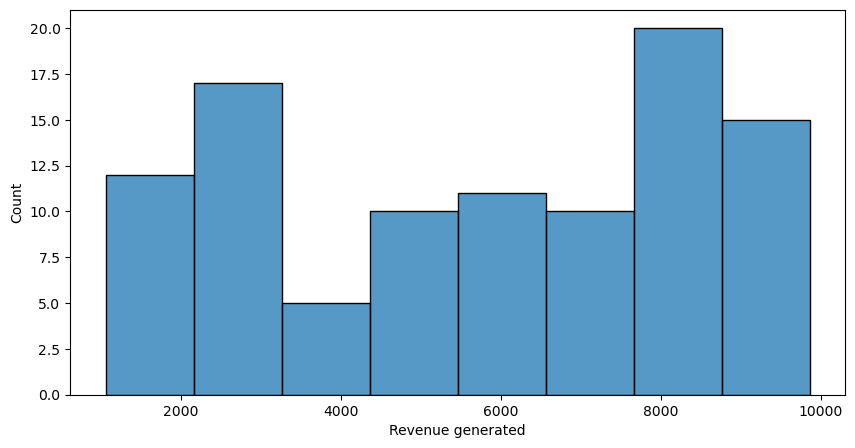

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Revenue generated']
)

plt.show()

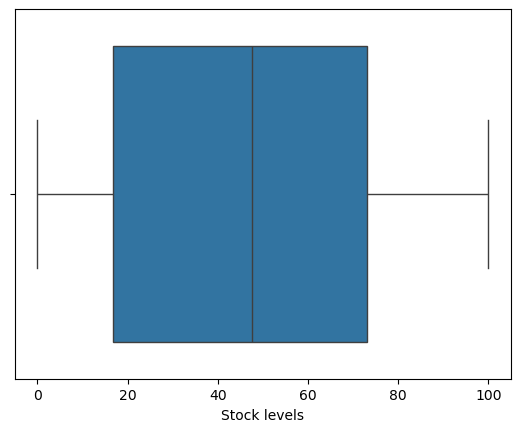

In [14]:
sns.boxplot(
    x=df['Stock levels']
)

plt.show()

In [15]:
supplier_perf = df.groupby(
    'Supplier name'
)[
    'Revenue generated'
].sum()

supplier_perf.sort_values(
    ascending=False
)

Supplier name
Supplier 1    157528.995039
Supplier 2    125467.418605
Supplier 5    110343.463656
Supplier 3     97795.979638
Supplier 4     86468.961799
Name: Revenue generated, dtype: float64

In [16]:
df['Inventory_Value'] = (
    df['Stock levels']
    * df['Price']
)

In [17]:
df[['SKU','Inventory_Value']].head()

,SKU,Inventory_Value
0,SKU0,4048.864321
1,SKU1,786.706734
2,SKU2,11.319683
3,SKU3,1406.756889
4,SKU4,24.027480


In [18]:
df['Reorder_Point'] = (
    df['Number of products sold']
    * df['Lead times']
)

In [19]:
df[['SKU','Reorder_Point']].head()

,SKU,Reorder_Point
0,SKU0,5614
1,SKU1,22080
2,SKU2,80
3,SKU3,1079
4,SKU4,2613


In [20]:
df['Stockout_Risk'] = (
    df['Stock levels']
    <
    df['Reorder_Point']
).astype(int)

In [21]:
df['Stockout_Risk'].value_counts()

Stockout_Risk
1    100
Name: count, dtype: int64

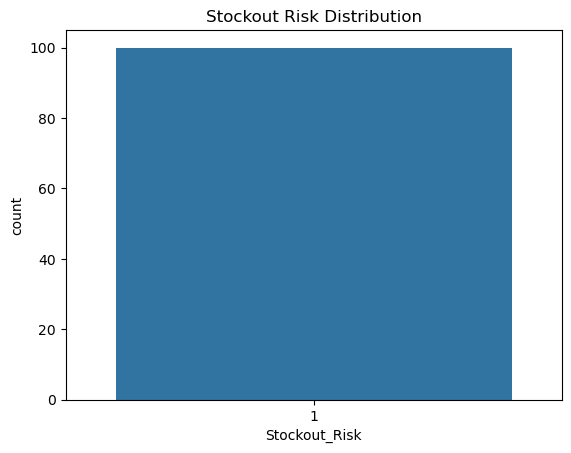

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='Stockout_Risk',
    data=df
)

plt.title("Stockout Risk Distribution")

plt.show()

In [23]:
features = [
    'Price',
    'Availability',
    'Number of products sold',
    'Revenue generated',
    'Stock levels',
    'Lead times',
    'Order quantities',
    'Production volumes',
    'Manufacturing costs'
]

X = df[features]

y = df['Stockout_Risk']

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
pred = model.predict(
    X_test
)

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    pred
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 1.0


In [28]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(
    'Importance',
    ascending=False
)

,Feature,Importance
0,Price,0.0
1,Availability,0.0
2,Number of products sold,0.0
3,Revenue generated,0.0
4,Stock levels,0.0
5,Lead times,0.0
6,Order quantities,0.0
7,Production volumes,0.0
8,Manufacturing costs,0.0


In [29]:
importance.to_csv(
    'feature_importance.csv',
    index=False
)

In [30]:
results = X_test.copy()

results['Actual'] = y_test.values

results['Predicted'] = pred

results.to_csv(
    'stockout_predictions.csv',
    index=False
)

In [31]:
print("Accuracy:", accuracy)

Accuracy: 1.0
